In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from statistics import mean, stdev

In [2]:
sns.set_style('darkgrid')
cmap=sns.light_palette("seagreen",as_cmap=True)
pd.set_option('display.float_format','{:.4f}'.format)

In [3]:
unfair = pd.read_csv('../benchmark/arrhythmia-age-result/unfair_lr-100.csv', index_col=0)
zhang = pd.read_csv('../benchmark/arrhythmia-age-result/zhang-100.csv', index_col=0)

In [4]:
unfair = unfair.drop([0,1,2,3,4], axis=0)
unfair

,model_name,cv_seed,clas_acc,dp,deqodds,deqopp,trade_dp,trade_deqodds,trade_deqopp,TN_a0,FP_a0,FN_a0,TP_a0,TN_a1,FP_a1,FN_a1,TP_a1
5,UnfairLR,13,0.5781,0.7729,0.7336,0.9579,0.6615,0.6466,0.7211,7.0000,20.0000,3.0000,16.0000,6.0000,2.0000,2.0000,8.0000
6,UnfairLR,29,0.7969,0.8730,0.8817,0.9617,0.8332,0.8371,0.8716,9.0000,5.0000,2.0000,20.0000,4.0000,5.0000,1.0000,18.0000
7,UnfairLR,42,0.6875,0.8833,0.9340,0.9306,0.7732,0.7920,0.7908,11.0000,11.0000,1.0000,17.0000,9.0000,7.0000,1.0000,7.0000
8,UnfairLR,55,0.6406,0.8433,0.8360,0.7986,0.7281,0.7254,0.7109,7.0000,10.0000,2.0000,16.0000,7.0000,6.0000,5.0000,11.0000
9,UnfairLR,73,0.6719,0.9380,0.8184,0.9145,0.7829,0.7379,0.7746,11.0000,7.0000,6.0000,21.0000,2.0000,4.0000,4.0000,9.0000


In [5]:
zhang

,model_name,cv_seed,clas_acc,dp,deqodds,deqopp,trade_dp,trade_deqodds,trade_deqopp,TN_a0,FP_a0,FN_a0,TP_a0,TN_a1,FP_a1,FN_a1,TP_a1
0,Zhang4DP,13,0.5938,0.7947,0.7568,0.8053,0.6797,0.6654,0.6835,9.0000,18.0000,2.0000,17.0000,5.0000,3.0000,3.0000,7.0000
1,Zhang4DP,29,0.7812,0.8929,0.9268,0.9091,0.8333,0.8478,0.8403,7.0000,7.0000,2.0000,20.0000,4.0000,5.0000,0.0000,19.0000
2,Zhang4DP,42,0.6094,0.9083,0.8747,0.9028,0.7294,0.7183,0.7276,9.0000,13.0000,4.0000,14.0000,9.0000,7.0000,1.0000,7.0000
3,Zhang4DP,55,0.6875,0.8148,0.7921,0.9236,0.7457,0.7361,0.7883,6.0000,11.0000,2.0000,16.0000,9.0000,4.0000,3.0000,13.0000
4,Zhang4DP,73,0.7031,0.7883,0.7806,0.8946,0.7433,0.7399,0.7874,12.0000,6.0000,7.0000,20.0000,2.0000,4.0000,2.0000,11.0000
5,Zhang4EqOdds,13,0.6094,0.8164,0.7753,0.8053,0.6979,0.6824,0.6938,10.0000,17.0000,2.0000,17.0000,5.0000,3.0000,3.0000,7.0000
6,Zhang4EqOdds,29,0.7812,0.8929,0.9268,0.9091,0.8333,0.8478,0.8403,7.0000,7.0000,2.0000,20.0000,4.0000,5.0000,0.0000,19.0000
7,Zhang4EqOdds,42,0.6094,0.9083,0.8747,0.9028,0.7294,0.7183,0.7276,9.0000,13.0000,4.0000,14.0000,9.0000,7.0000,1.0000,7.0000
8,Zhang4EqOdds,55,0.6875,0.8148,0.7921,0.9236,0.7457,0.7361,0.7883,6.0000,11.0000,2.0000,16.0000,9.0000,4.0000,3.0000,13.0000
9,Zhang4EqOdds,73,0.7031,0.7883,0.7806,0.8946,0.7433,0.7399,0.7874,12.0000,6.0000,7.0000,20.0000,2.0000,4.0000,2.0000,11.0000


## Acc mean and std

In [6]:
unfair_acc = unfair.groupby(['model_name'])['clas_acc'].agg([mean, stdev])
zhang_acc = zhang.groupby(['model_name'])['clas_acc'].agg([mean, stdev])

In [7]:
acc = pd.concat([unfair_acc, zhang_acc])
acc = acc.reset_index()
acc = acc.rename(columns={'index': 'model_name'})
acc

,model_name,mean,stdev
0,UnfairLR,0.6750,0.0800
1,Zhang4DP,0.6750,0.0761
2,Zhang4EqOdds,0.6781,0.0721
3,Zhang4EqOpp,0.6844,0.0736


In [8]:
names = acc['model_name'].to_list()
for i in range(len(names)):
    if isinstance(names[i], tuple):
        names[i] = '-'.join([str(value) for value in names[i]])

names

['UnfairLR', 'Zhang4DP', 'Zhang4EqOdds', 'Zhang4EqOpp']

In [9]:
acc['model_name'] = names
acc

,model_name,mean,stdev
0,UnfairLR,0.6750,0.0800
1,Zhang4DP,0.6750,0.0761
2,Zhang4EqOdds,0.6781,0.0721
3,Zhang4EqOpp,0.6844,0.0736


In [10]:
print((acc['mean'].round(4).astype(str) + ' $\pm$ ' + acc['stdev'].round(4).astype(str)).to_string(index=False))

   0.675 $\pm$ 0.08
 0.675 $\pm$ 0.0761
0.6781 $\pm$ 0.0721
0.6844 $\pm$ 0.0736


## Fairness mean and std

In [11]:
unfair_dp = unfair.groupby(['model_name'])['dp'].agg([mean, stdev])
zhang_dp = zhang.groupby(['model_name'])['dp'].agg([mean, stdev])

In [12]:
dp = pd.concat([unfair_dp, zhang_dp])
dp = dp.reset_index()
dp = dp.rename(columns={'index': 'model_name'})
dp['model_name'] = names
dp

,model_name,mean,stdev
0,UnfairLR,0.8621,0.0605
1,Zhang4DP,0.8398,0.0566
2,Zhang4EqOdds,0.8441,0.0530
3,Zhang4EqOpp,0.8657,0.0498


In [13]:
print((dp['mean'].round(4).astype(str) + ' $\pm$ ' + dp['stdev'].round(4).astype(str)).to_string(index=False))

0.8621 $\pm$ 0.0605
0.8398 $\pm$ 0.0566
 0.8441 $\pm$ 0.053
0.8657 $\pm$ 0.0498


In [14]:
unfair_deqodds = unfair.groupby(['model_name'])['deqodds'].agg([mean, stdev])
zhang_deqodds = zhang.groupby(['model_name'])['deqodds'].agg([mean, stdev])

In [15]:
deqodds = pd.concat([unfair_deqodds, zhang_deqodds])
deqodds = deqodds.reset_index()
deqodds = deqodds.rename(columns={'index': 'model_name'})
deqodds['model_name'] = names
deqodds

,model_name,mean,stdev
0,UnfairLR,0.8407,0.0748
1,Zhang4DP,0.8262,0.0716
2,Zhang4EqOdds,0.8299,0.0675
3,Zhang4EqOpp,0.8695,0.0635


In [16]:
print((deqodds['mean'].round(4).astype(str) + ' $\pm$ ' + deqodds['stdev'].round(4).astype(str)).to_string(index=False))

0.8407 $\pm$ 0.0748
0.8262 $\pm$ 0.0716
0.8299 $\pm$ 0.0675
0.8695 $\pm$ 0.0635


In [17]:
unfair_deqopp = unfair.groupby(['model_name'])['deqopp'].agg([mean, stdev])
zhang_deqopp = zhang.groupby(['model_name'])['deqopp'].agg([mean, stdev])

In [18]:
deqopp = pd.concat([unfair_deqopp, zhang_deqopp])
deqopp = deqopp.reset_index()
deqopp = deqopp.rename(columns={'index': 'model_name'})
deqopp['model_name'] = names
deqopp

,model_name,mean,stdev
0,UnfairLR,0.9127,0.0667
1,Zhang4DP,0.8871,0.0469
2,Zhang4EqOdds,0.8871,0.0469
3,Zhang4EqOpp,0.9385,0.0339


In [19]:
print((deqopp['mean'].round(4).astype(str) + ' $\pm$ ' + deqopp['stdev'].round(4).astype(str)).to_string(index=False))

0.9127 $\pm$ 0.0667
0.8871 $\pm$ 0.0469
0.8871 $\pm$ 0.0469
0.9385 $\pm$ 0.0339


## Trade-offs mean and std

In [20]:
unfair_trade_dp = unfair.groupby(['model_name'])['trade_dp'].agg([mean, stdev])
zhang_trade_dp = zhang.groupby(['model_name'])['trade_dp'].agg([mean, stdev])

In [21]:
trade_dp = pd.concat([unfair_trade_dp, zhang_trade_dp])
trade_dp = trade_dp.reset_index()
trade_dp = trade_dp.rename(columns={'index': 'model_name'})
trade_dp['model_name'] = names
trade_dp

,model_name,mean,stdev
0,UnfairLR,0.7558,0.0646
1,Zhang4DP,0.7463,0.0555
2,Zhang4EqOdds,0.7499,0.0504
3,Zhang4EqOpp,0.7626,0.0531


In [22]:
print((trade_dp['mean'].round(4).astype(str) + ' $\pm$ ' + trade_dp['stdev'].round(4).astype(str)).to_string(index=False))

0.7558 $\pm$ 0.0646
0.7463 $\pm$ 0.0555
0.7499 $\pm$ 0.0504
0.7626 $\pm$ 0.0531


In [23]:
unfair_trade_deqodds = unfair.groupby(['model_name'])['trade_deqodds'].agg([mean, stdev])
zhang_trade_deqodds = zhang.groupby(['model_name'])['trade_deqodds'].agg([mean, stdev])

In [24]:
trade_deqodds = pd.concat([unfair_trade_deqodds, zhang_trade_deqodds])
trade_deqodds = trade_deqodds.reset_index()
trade_deqodds = trade_deqodds.rename(columns={'index': 'model_name'})
trade_deqodds['model_name'] = names
trade_deqodds

,model_name,mean,stdev
0,UnfairLR,0.7478,0.0721
1,Zhang4DP,0.7415,0.0664
2,Zhang4EqOdds,0.7449,0.0619
3,Zhang4EqOpp,0.7644,0.0607


In [25]:
print((trade_deqodds['mean'].round(4).astype(str) + ' $\pm$ ' + trade_deqodds['stdev'].round(4).astype(str)).to_string(index=False))

0.7478 $\pm$ 0.0721
0.7415 $\pm$ 0.0664
0.7449 $\pm$ 0.0619
0.7644 $\pm$ 0.0607


In [26]:
unfair_trade_deqopp = unfair.groupby(['model_name'])['trade_deqopp'].agg([mean, stdev])
zhang_trade_deqopp = zhang.groupby(['model_name'])['trade_deqopp'].agg([mean, stdev])

In [27]:
trade_deqopp = pd.concat([unfair_trade_deqopp, zhang_trade_deqopp])
trade_deqopp = trade_deqopp.reset_index()
trade_deqopp = trade_deqopp.rename(columns={'index': 'model_name'})
trade_deqopp['model_name'] = names
trade_deqopp

,model_name,mean,stdev
0,UnfairLR,0.7738,0.0644
1,Zhang4DP,0.7654,0.0607
2,Zhang4EqOdds,0.7675,0.0574
3,Zhang4EqOpp,0.7897,0.0508


In [28]:
print((trade_deqopp['mean'].round(4).astype(str) + ' $\pm$ ' + trade_deqopp['stdev'].round(4).astype(str)).to_string(index=False))

0.7738 $\pm$ 0.0644
0.7654 $\pm$ 0.0607
0.7675 $\pm$ 0.0574
0.7897 $\pm$ 0.0508


## t-test

In [29]:
unfair_lr= unfair
zhang4dp, zhang4deqodds, zhang4deqopp = [x for _, x in zhang.groupby(['model_name'])]

In [30]:
models = [
    unfair_lr,
    zhang4dp, zhang4deqodds, zhang4deqopp
]

In [31]:
alpha = 0.05 # significance level
confidence = 1 - alpha # confidence level
l = len(models)

In [32]:
base_df = pd.DataFrame(index=names, columns=names, dtype=object)

### for accuracies

In [33]:
res_acc = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['clas_acc'], models[j]['clas_acc'])
        res_acc.iloc[i, j] = stat[1]

In [34]:
res_acc.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,1.0000,-,-,-
Zhang4EqOdds,0.8979,0.3739,-,-
Zhang4EqOpp,0.5913,0.5291,0.6885,-


### for fairness

In [35]:
res_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['dp'], models[j]['dp'])
        res_dp.iloc[i, j] = stat[1]

In [36]:
res_dp.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.5395,-,-,-
Zhang4EqOdds,0.6344,0.3739,-,-
Zhang4EqOpp,0.9273,0.4722,0.5458,-


In [37]:
res_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['deqodds'], models[j]['deqodds'])
        res_deqodds.iloc[i, j] = stat[1]

In [38]:
res_deqodds.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.5175,-,-,-
Zhang4EqOdds,0.6549,0.3739,-,-
Zhang4EqOpp,0.2889,0.1408,0.1795,-


In [39]:
res_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['deqopp'], models[j]['deqopp'])
        res_deqopp.iloc[i, j] = stat[1]

In [40]:
res_deqopp.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.5959,-,-,-
Zhang4EqOdds,0.5959,-,-,-
Zhang4EqOpp,0.5832,0.0420,0.0420,-


### for trade-offs

In [41]:
res_trade_dp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['trade_dp'], models[j]['trade_dp'])
        res_trade_dp.iloc[i, j] = stat[1]

In [42]:
res_trade_dp.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.5220,-,-,-
Zhang4EqOdds,0.7280,0.3739,-,-
Zhang4EqOpp,0.6644,0.0797,0.2035,-


In [43]:
res_trade_deqodds = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['trade_deqodds'], models[j]['trade_deqodds'])
        res_trade_deqodds.iloc[i, j] = stat[1]

In [44]:
res_trade_deqodds.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.7301,-,-,-
Zhang4EqOdds,0.8828,0.3739,-,-
Zhang4EqOpp,0.3146,0.0336,0.0978,-


In [45]:
res_trade_deqopp = base_df.copy()
for i in range(0, l-1):
    for j in range(i+1, l):
        stat = stats.ttest_rel(models[i]['trade_deqopp'], models[j]['trade_deqopp'])
        res_trade_deqopp.iloc[i, j] = stat[1]

In [46]:
res_trade_deqopp.T.fillna('-')

,UnfairLR,Zhang4DP,Zhang4EqOdds,Zhang4EqOpp
UnfairLR,-,-,-,-
Zhang4DP,0.7511,-,-,-
Zhang4EqOdds,0.8060,0.3739,-,-
Zhang4EqOpp,0.5060,0.0851,0.0995,-


## Plotting Accuracies

In [47]:
model_names = unfair['model_name'].to_list()
model_names += zhang['model_name'].to_list()

In [48]:
model_names

['UnfairLR',
 'UnfairLR',
 'UnfairLR',
 'UnfairLR',
 'UnfairLR',
 'Zhang4DP',
 'Zhang4DP',
 'Zhang4DP',
 'Zhang4DP',
 'Zhang4DP',
 'Zhang4EqOdds',
 'Zhang4EqOdds',
 'Zhang4EqOdds',
 'Zhang4EqOdds',
 'Zhang4EqOdds',
 'Zhang4EqOpp',
 'Zhang4EqOpp',
 'Zhang4EqOpp',
 'Zhang4EqOpp',
 'Zhang4EqOpp']

In [49]:
model_accs = unfair['clas_acc'].to_list()+zhang['clas_acc'].to_list()

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86208/1516234898.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


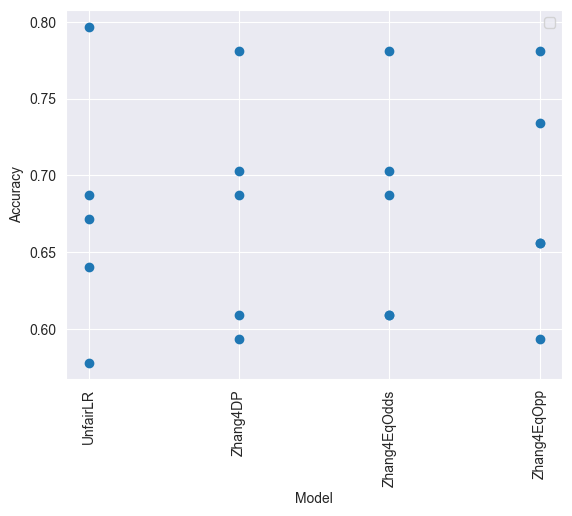

In [50]:
plt.plot()
plt.ylabel('Accuracy')

plt.scatter(model_names, model_accs)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Demographic Disparities

In [51]:
model_dps = unfair['dp'].to_list()+zhang['dp'].to_list()

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86208/2479496912.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


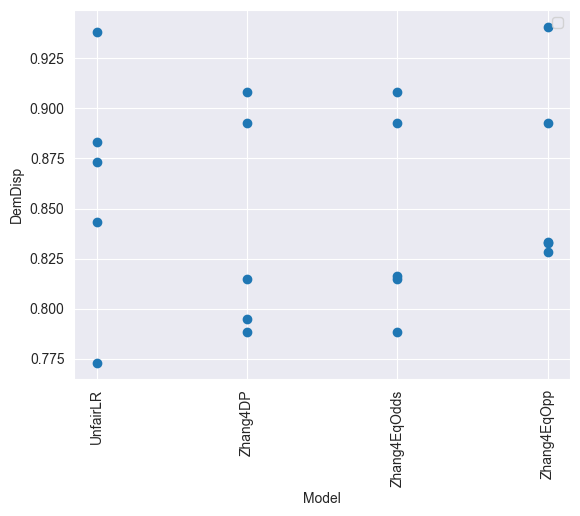

In [52]:
plt.plot()
plt.ylabel('DemDisp')

plt.scatter(model_names, model_dps)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Disparity in Equal Odds

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86208/1034882315.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


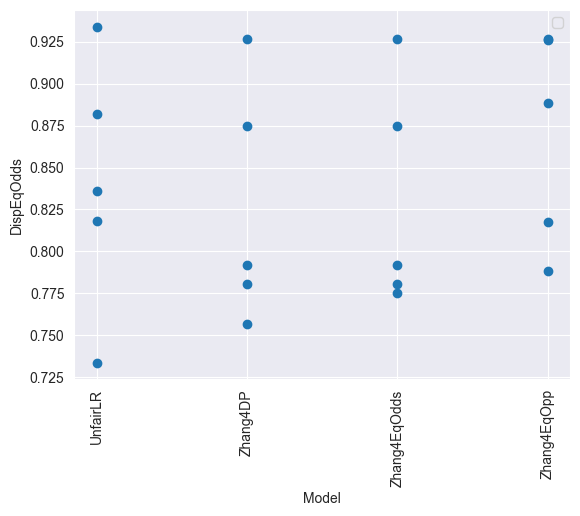

In [53]:
model_deqodds = unfair['deqodds'].to_list()+zhang['deqodds'].to_list()
plt.plot()
plt.ylabel('DispEqOdds')

plt.scatter(model_names, model_deqodds)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Disparity in Equal Opp

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86208/755552296.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


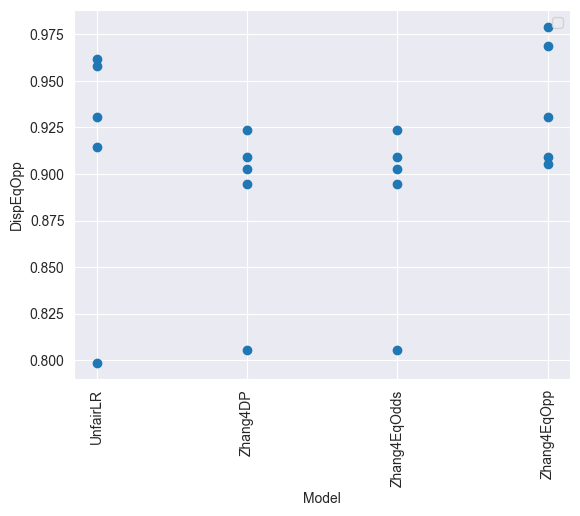

In [54]:
model_deqopps = unfair['deqopp'].to_list()+zhang['deqopp'].to_list()
plt.plot()
plt.ylabel('DispEqOpp')

plt.scatter(model_names, model_deqopps)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Trade-off Acc-DemDisp

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86208/3481502659.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


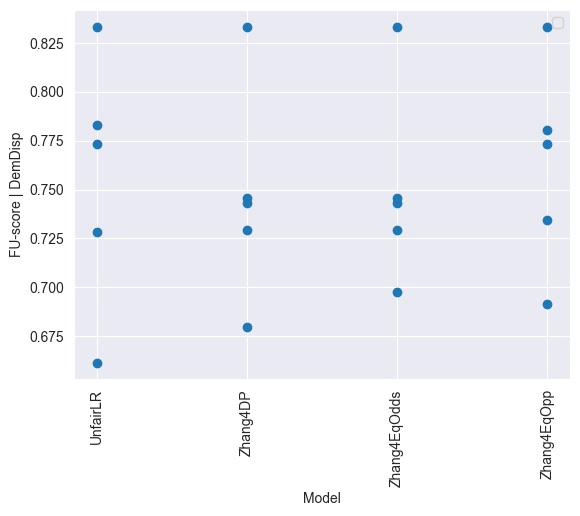

In [55]:
model_trade_dp = unfair['trade_dp'].to_list()+zhang['trade_dp'].to_list()
plt.plot()
plt.ylabel('FU-score | DemDisp')

plt.scatter(model_names, model_trade_dp)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Trade-off Acc-DispEqOdds

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86208/1478964109.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


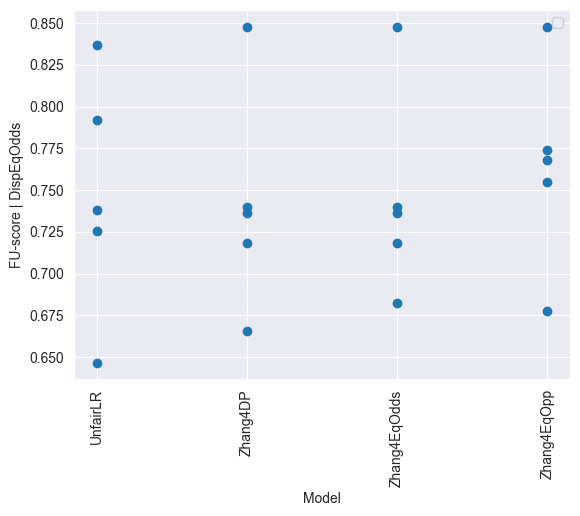

In [56]:
model_trade_deqodds = unfair['trade_deqodds'].to_list()+zhang['trade_deqodds'].to_list()
plt.plot()
plt.ylabel('FU-score | DispEqOdds')

plt.scatter(model_names, model_trade_deqodds)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Trade-off Acc-DispEqOpp

/var/folders/nx/ktkztyln3xn8f8j2qrfpjrlh0000gn/T/ipykernel_86208/1705168636.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


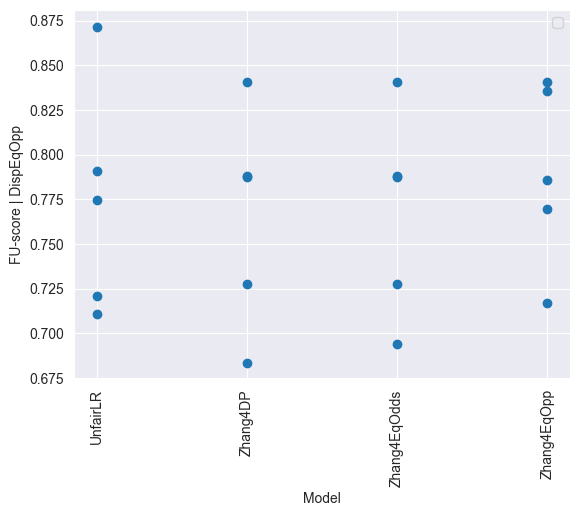

In [57]:
model_trade_deqopp = unfair['trade_deqopp'].to_list()+zhang['trade_deqopp'].to_list()
plt.plot()
plt.ylabel('FU-score | DispEqOpp')

plt.scatter(model_names, model_trade_deqopp)#, label = "ZHANG DemPar")

plt.xlabel('Model')
plt.xticks(rotation=90)
plt.legend()
plt.show()

## Plotting Acc x DemDisp

In [58]:
'''cmap=sns.light_palette("seagreen")#,as_cmap=True)
cmap'''

'cmap=sns.light_palette("seagreen")#,as_cmap=True)\ncmap'

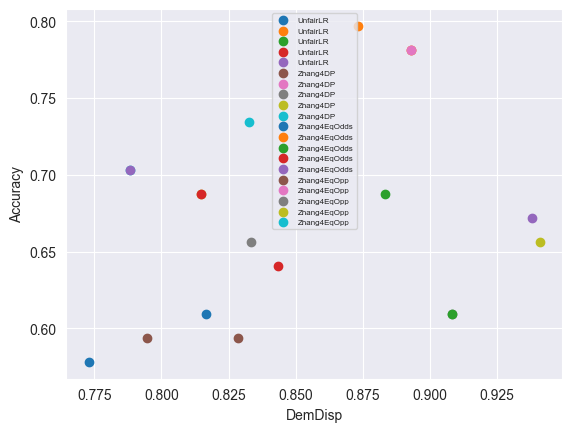

<Figure size 700x700 with 0 Axes>

In [59]:
plt.plot()
#sns.light_palette("seagreen",as_cmap=True)

#fig, ax = plt.scatter(model_dps, model_accs)#, label = "ZHANG DemPar")
'''fig, ax = plt.subplots()
ax.scatter(model_dps, model_accs)'''

plt.xlabel('DemDisp')
plt.ylabel('Accuracy')

for i, model_name in enumerate(model_names):
    plt.scatter(model_dps[i], model_accs[i], label=model_name)#, color=cmap[i])
plt.legend(loc='upper center', fontsize='xx-small')
plt.figure(figsize=(7,7))

plt.show()

## Plotting Acc x DispEqOdds

## Plotting Acc x DispEqOpp

# Pro artigo

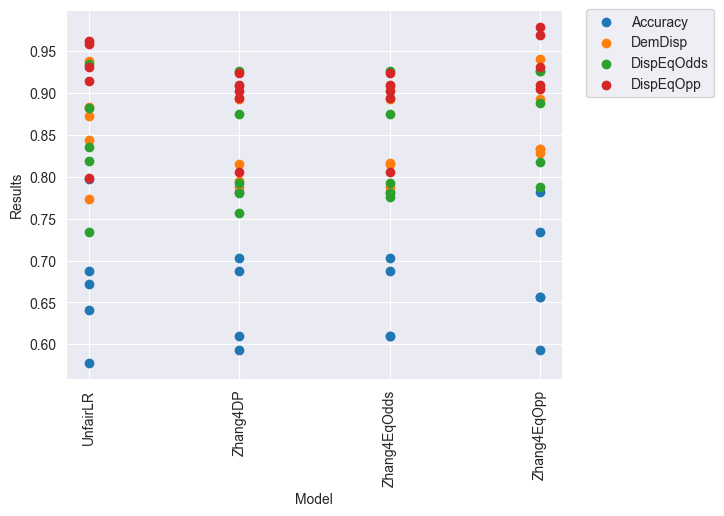

In [60]:

plt.plot()
plt.ylabel('Results')

plt.scatter(model_names, model_accs)
plt.scatter(model_names, model_dps)
plt.scatter(model_names, model_deqodds)
plt.scatter(model_names, model_deqopps)#, label = "ZHANG DemPar")


plt.xlabel('Model')
plt.xticks(rotation=90)
#plt.figure(figsize=(15,12))
#plt.yticks(range(0.755, 0.985))
#plt.yscale('log')
#plt.yticks([0.755, 0.80, 0.805, 0.81, 0.815, 0.82, 0.825, 0.83, 0.835, 0.84, 0.845, 0.85, 0.855, 0.86, 0.865, 0.87, 0.875, 0.88, 0.885, 0.89, 0.895, 0.90, 0.905, 0.91, 0.915, 0.92, 0.925, 0.93, 0.935, 0.94, 0.945, 0.95, 0.955, 0.96, 0.965, 0.97, 0.975,0.98, 0.985])
plt.legend(['Accuracy', 'DemDisp', 'DispEqOdds', 'DispEqOpp'], bbox_to_anchor=(1.32,1.02), loc="upper right")
plt.show()

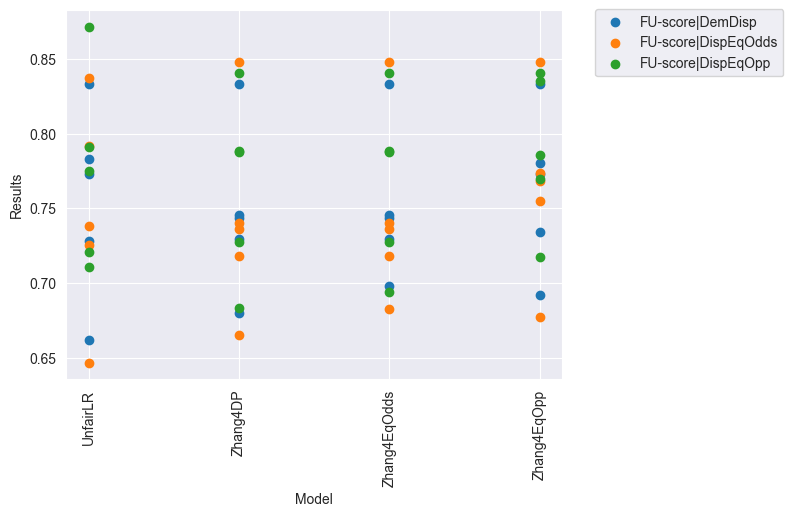

In [61]:

plt.plot()
plt.ylabel('Results')

plt.scatter(model_names, model_trade_dp)
plt.scatter(model_names, model_trade_deqodds)
plt.scatter(model_names, model_trade_deqopp)#, label = "ZHANG DemPar")


plt.xlabel('Model')
plt.xticks(rotation=90)
#plt.figure(figsize=(15,12))
#plt.yticks(range(0.755, 0.985))
#plt.yscale('log')
#plt.yticks([0.755, 0.80, 0.805, 0.81, 0.815, 0.82, 0.825, 0.83, 0.835, 0.84, 0.845, 0.85, 0.855, 0.86, 0.865, 0.87, 0.875, 0.88, 0.885, 0.89, 0.895, 0.90, 0.905, 0.91, 0.915, 0.92, 0.925, 0.93, 0.935, 0.94, 0.945, 0.95, 0.955, 0.96, 0.965, 0.97, 0.975,0.98, 0.985])
plt.legend(['FU-score|DemDisp', 'FU-score|DispEqOdds', 'FU-score|DispEqOpp'], bbox_to_anchor=(1.46,1.02), loc="upper right")
plt.show()